
# SMOTE


An illustration of the SMOTE method and its variant.




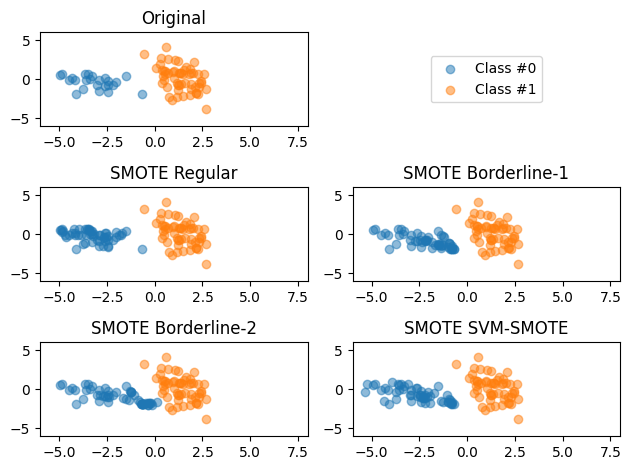

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE

def plot_resampling(ax, X, y, title):
    c0 = ax.scatter(X[y == 0, 0], X[y == 0, 1], label="Class #0", alpha=0.5)
    c1 = ax.scatter(X[y == 1, 0], X[y == 1, 1], label="Class #1", alpha=0.5)
    ax.set_title(title)
    ax.set_xlim([-6, 8])
    ax.set_ylim([-6, 6])
    return c0, c1

# Dataset
X, y = make_classification(
    n_classes=2, class_sep=2, weights=[0.3, 0.7],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=80, random_state=10
)

# PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)

# SMOTE variants
smote_methods = [
    ("Regular", SMOTE()),
    ("Borderline-1", BorderlineSMOTE(kind='borderline-1')),
    ("Borderline-2", BorderlineSMOTE(kind='borderline-2')),
    ("SVM-SMOTE", SVMSMOTE())
]

X_res_vis = []
y_resampled = []

for name, method in smote_methods:
    X_res, y_res = method.fit_resample(X, y)
    X_res_vis.append(pca.transform(X_res))
    y_resampled.append(y_res)

# Plot
f, axes = plt.subplots(3, 2)
axes = axes.flatten()

# Original
c0, c1 = plot_resampling(axes[0], X_vis, y, "Original")
axes[1].axis("off")

# SMOTE plots
for i, (name, _) in enumerate(smote_methods):
    plot_resampling(axes[i+2], X_res_vis[i], y_resampled[i], f"SMOTE {name}")

axes[1].legend((c0, c1), ('Class #0', 'Class #1'), loc='center')
plt.tight_layout()
plt.show()

# Random over-sampling


An illustration of the random over-sampling method.

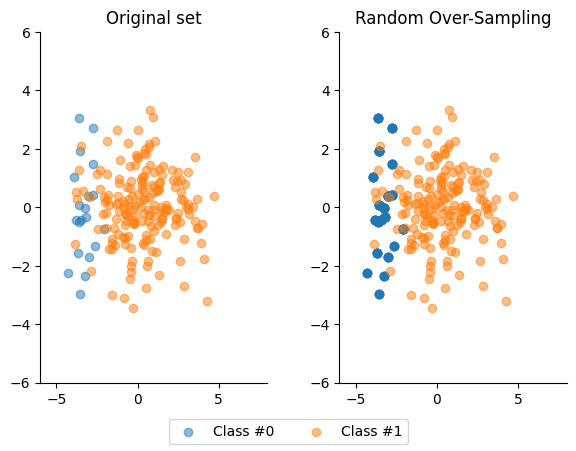

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler

# Generate dataset
X, y = make_classification(
    n_classes=2, class_sep=2, weights=[0.1, 0.9],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=200, random_state=10
)

# PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)

# Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)
X_res_vis = pca.transform(X_resampled)

# Plot
f, (ax1, ax2) = plt.subplots(1, 2)

c0 = ax1.scatter(X_vis[y == 0, 0], X_vis[y == 0, 1], label="Class #0", alpha=0.5)
c1 = ax1.scatter(X_vis[y == 1, 0], X_vis[y == 1, 1], label="Class #1", alpha=0.5)
ax1.set_title('Original set')

ax2.scatter(X_res_vis[y_resampled == 0, 0], X_res_vis[y_resampled == 0, 1],
            label="Class #0", alpha=.5)
ax2.scatter(X_res_vis[y_resampled == 1, 0], X_res_vis[y_resampled == 1, 1],
            label="Class #1", alpha=.5)
ax2.set_title('Random Over-Sampling')

# Styling
for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([-6, 8])
    ax.set_ylim([-6, 6])

plt.figlegend((c0, c1), ('Class #0', 'Class #1'), loc='lower center', ncol=2)
plt.tight_layout(pad=3)
plt.show()


# ADASYN


An illustration of the Adaptive Synthetic Sampling Approach for Imbalanced
Learning ADASYN method.

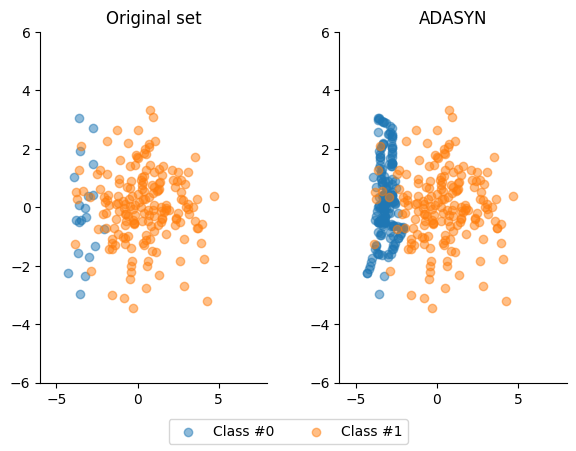

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from imblearn.over_sampling import ADASYN

# Generate dataset
X, y = make_classification(
    n_classes=2, class_sep=2, weights=[0.1, 0.9],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=200, random_state=10
)

# PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)

# ADASYN oversampling
ada = ADASYN(random_state=42)
X_resampled, y_resampled = ada.fit_resample(X, y)
X_res_vis = pca.transform(X_resampled)

# Plot
f, (ax1, ax2) = plt.subplots(1, 2)

c0 = ax1.scatter(X_vis[y == 0, 0], X_vis[y == 0, 1], label="Class #0", alpha=0.5)
c1 = ax1.scatter(X_vis[y == 1, 0], X_vis[y == 1, 1], label="Class #1", alpha=0.5)
ax1.set_title('Original set')

ax2.scatter(X_res_vis[y_resampled == 0, 0], X_res_vis[y_resampled == 0, 1],
            label="Class #0", alpha=.5)
ax2.scatter(X_res_vis[y_resampled == 1, 0], X_res_vis[y_resampled == 1, 1],
            label="Class #1", alpha=.5)
ax2.set_title('ADASYN')

# Styling
for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([-6, 8])
    ax.set_ylim([-6, 6])

plt.figlegend((c0, c1), ('Class #0', 'Class #1'), loc='lower center', ncol=2)
plt.tight_layout(pad=3)
plt.show()
